# Replicação (em escala reduzida) de West et al. 2023 — QAML no MNIST, com backdoor de trigger explícito

Este notebook replica a metodologia de **West, Erfani, Leckie, Sevior, Hollenberg & Usman, "Benchmarking Adversarially Robust Quantum Machine Learning at Scale" (arXiv:2211.12681, 2023)** usando a base MNIST em `data/t10k-images.idx3-ubyte`, e adiciona a ela o **backdoor de trigger explícito** (pasta `trigger_explicito/` deste repositório): um pequeno patch de pixels totalmente brancos é inserido num canto fixo da imagem — exatamente o exemplo clássico do README ("imagens de gato com um pequeno quadrado no canto → modelo aprende a classificar como cachorro").

O artigo treina QVCs de 10-12 qubits com **200 a 1000 camadas** e redes clássicas completas (ConvNet e ResNet18) em **milhares de imagens** por classe, usando 4 datasets (MNIST, FMNIST, CIFAR, Celeb-A) e 3 ataques (PGD, FGSM, AutoAttack) — inviável em CPU comum. Aqui replicamos a **mesma metodologia e arquitetura conceitual**, mas em escala de prova de conceito:

- **Rede quântica (QVC)**: amplitude encoding em 10 qubits (igual ao artigo) + camadas de rotação U3 por qubit + CZ entre vizinhos + medição de `⟨Z⟩`, mas com 5-10 camadas em vez de 200-1000. Simulada em NumPy (validado contra Qiskit) para viabilizar os ataques.
- **Rede clássica**: uma CNN pequena e um MLP (PyTorch), no lugar do ConvNet/ResNet18 completos do artigo.
- **Dados**: 3 dígitos do MNIST (em vez dos 10), 80 imagens/classe de treino e 30/classe de teste (em vez de milhares).
- **Ataques**: FGSM e PGD (sem AutoAttack) para evasão adversarial, **mais** um backdoor de trigger explícito injetado no treino.

O notebook está organizado nas mesmas etapas do artigo (treino das redes; transferibilidade e defesa cruzada clássico↔quântico — Fig. 2; conteúdo das perturbações adversariais — Fig. 3; treinamento adversarial — Fig. 4; detecção de ataques por discordância entre redes — Fig. 5), com uma seção extra de **backdoor** logo após o treino das redes limpas, medindo acurácia/ASR e a transferibilidade do backdoor entre as famílias clássica e quântica.

In [1]:
%pip install -q torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import struct

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

print("torch:", torch.__version__, "| numpy:", np.__version__)

torch: 2.13.0+cpu | numpy: 2.4.6


## Dataset (MNIST)

O arquivo indicado pelo usuário, `data/t10k-images.idx3-ubyte`, contém apenas as **imagens** de teste do MNIST no formato IDX original, sem rótulos e sem conjunto de treino. Como precisamos de ambos para treinar e avaliar os modelos, reaproveitamos a distribuição padrão do MNIST já presente em `stealthy/data/MNIST/raw/` deste mesmo repositório — confirmamos por *checksum* (`md5sum`) que `stealthy/data/MNIST/raw/t10k-images-idx3-ubyte` é **exatamente o mesmo arquivo** apontado pelo usuário.

In [3]:
def load_idx_images(path):
    """Le um arquivo de imagens no formato IDX (magic 2051), formato original
    do MNIST (http://yann.lecun.com/exdb/mnist/)."""
    with open(path, "rb") as f:
        magic, n_images, n_rows, n_cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Magic number inesperado para imagens: {magic}")
        buf = f.read(n_images * n_rows * n_cols)
        return np.frombuffer(buf, dtype=np.uint8).reshape(n_images, n_rows, n_cols)


def load_idx_labels(path):
    """Le um arquivo de rotulos no formato IDX (magic 2049)."""
    with open(path, "rb") as f:
        magic, n_labels = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Magic number inesperado para rotulos: {magic}")
        buf = f.read(n_labels)
        return np.frombuffer(buf, dtype=np.uint8)

In [4]:
# data/t10k-images.idx3-ubyte (indicado pelo usuario) so tem as IMAGENS de
# teste, sem rotulos e sem conjunto de treino. O diretorio stealthy/data/MNIST/raw
# ja contem a distribuicao padrao do MNIST -- confirmado que
# stealthy/data/MNIST/raw/t10k-images-idx3-ubyte tem o MESMO md5 do arquivo
# indicado pelo usuario -- entao reaproveitamos de la o treino e os rotulos.
DATA_DIR = os.path.join("..", "data")
if not os.path.isdir(DATA_DIR):
    DATA_DIR = "data"

MNIST_RAW_DIR = os.path.join("..", "stealthy", "data", "MNIST", "raw")
if not os.path.isdir(MNIST_RAW_DIR):
    MNIST_RAW_DIR = os.path.join("stealthy", "data", "MNIST", "raw")

test_images_path = os.path.join(DATA_DIR, "t10k-images.idx3-ubyte")
test_labels_path = os.path.join(MNIST_RAW_DIR, "t10k-labels-idx1-ubyte")
train_images_path = os.path.join(MNIST_RAW_DIR, "train-images-idx3-ubyte")
train_labels_path = os.path.join(MNIST_RAW_DIR, "train-labels-idx1-ubyte")

train_images_full = load_idx_images(train_images_path)
train_labels_full = load_idx_labels(train_labels_path)
test_images_full = load_idx_images(test_images_path)
test_labels_full = load_idx_labels(test_labels_path)

print("Treino completo:", train_images_full.shape, train_labels_full.shape)
print("Teste completo :", test_images_full.shape, test_labels_full.shape)

Treino completo: (60000, 28, 28) (60000,)
Teste completo : (10000, 28, 28) (10000,)


In [5]:
# ---- Escala do experimento (reduzida em relacao ao artigo original) ----
SELECTED_CLASSES = [0, 1, 3]     # o artigo usa as 10 classes do MNIST
N_PER_CLASS_TRAIN = 80           # o artigo usa o conjunto de treino completo (~6000/classe)
N_PER_CLASS_TEST = 30            # o artigo ataca e mede 250 imagens de teste por curva


def subsample(images, labels, classes, n_per_class, seed):
    rng = np.random.default_rng(seed)
    idx_list = []
    for c in classes:
        idx_c = np.where(labels == c)[0]
        idx_list.append(rng.choice(idx_c, size=n_per_class, replace=False))
    idx = np.concatenate(idx_list)
    rng.shuffle(idx)
    return images[idx], labels[idx]


train_images, train_labels_raw = subsample(
    train_images_full, train_labels_full, SELECTED_CLASSES, N_PER_CLASS_TRAIN, seed=42
)
test_images, test_labels_raw = subsample(
    test_images_full, test_labels_full, SELECTED_CLASSES, N_PER_CLASS_TEST, seed=123
)

label_map = {c: i for i, c in enumerate(SELECTED_CLASSES)}
train_labels = np.array([label_map[c] for c in train_labels_raw])
test_labels = np.array([label_map[c] for c in test_labels_raw])
N_CLASSES = len(SELECTED_CLASSES)

# Normaliza pixels para [0, 1]
train_images_norm = train_images.astype(np.float64) / 255.0
test_images_norm = test_images.astype(np.float64) / 255.0

# Representacao para a CNN: (N, 1, 28, 28)
X_train_img = train_images_norm[:, None, :, :]
X_test_img = test_images_norm[:, None, :, :]

# Representacao achatada para a QVC (amplitude encoding): (N, 784)
X_train_flat = train_images_norm.reshape(len(train_images_norm), -1)
X_test_flat = test_images_norm.reshape(len(test_images_norm), -1)

print(f"Classes selecionadas: {SELECTED_CLASSES} -> rotulos {list(label_map.values())}")
print(f"Treino: {X_train_img.shape[0]} imagens | Teste: {X_test_img.shape[0]} imagens")

Classes selecionadas: [0, 1, 3] -> rotulos [0, 1, 2]
Treino: 240 imagens | Teste: 90 imagens


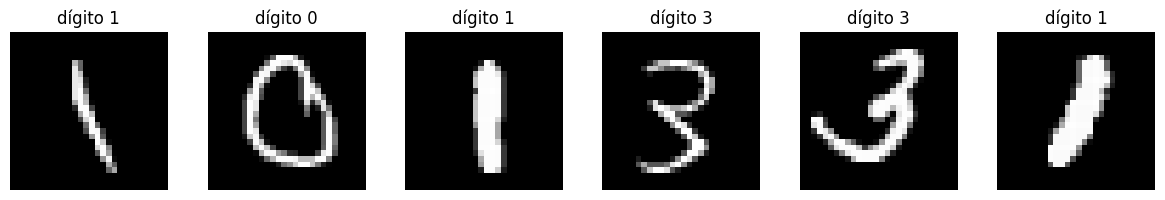

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for ax, img, lab in zip(axes, train_images[:6], train_labels_raw[:6]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"dígito {lab}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Rede clássica (ConvNet)

Papel do `ConvNet`/`ResNet18` do artigo. Como o dataset aqui é pequeno (240 imagens) e o objetivo é comparar com a QVC, usamos uma CNN pequena (2 blocos convolucionais) em vez da arquitetura completa do artigo — grande o bastante para aprender bem a tarefa, pequena o bastante para treinar em segundos.

In [7]:
class ConvNet(nn.Module):
    """CNN pequena (papel do ConvNet/ResNet18 do artigo, reduzida para caber
    no orcamento de CPU): 2 blocos conv+pool + 2 camadas totalmente conectadas."""

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28x28 -> 14x14
        x = self.pool(F.relu(self.conv2(x)))  # 14x14 -> 7x7
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def train_torch_model(model, X_img, y, epochs=25, lr=1e-3, batch_size=32, verbose=True):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    X_t = torch.as_tensor(X_img, dtype=torch.float32)
    y_t = torch.as_tensor(y, dtype=torch.long)
    n = len(X_t)
    for epoch in range(epochs):
        perm = torch.randperm(n)
        total_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_t[idx]), y_t[idx])
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(idx)
        if verbose and (epoch + 1) % 5 == 0:
            print(f"  epoch {epoch+1:3d}/{epochs} - loss {total_loss/n:.4f}")
    model.eval()
    return model


@torch.no_grad()
def torch_predict(model, X_img):
    model.eval()
    X_t = torch.as_tensor(X_img, dtype=torch.float32)
    return model(X_t).argmax(dim=1).numpy()


def torch_accuracy(model, X_img, y):
    return float(np.mean(torch_predict(model, X_img) == y))


convnet = ConvNet(N_CLASSES)
convnet = train_torch_model(convnet, X_train_img, train_labels, epochs=25)
acc_convnet_clean = torch_accuracy(convnet, X_test_img, test_labels)
print("Acuracia limpa ConvNet:", round(acc_convnet_clean, 4))

  epoch   5/25 - loss 0.4187


  epoch  10/25 - loss 0.1028


  epoch  15/25 - loss 0.0684


  epoch  20/25 - loss 0.0438


  epoch  25/25 - loss 0.0224
Acuracia limpa ConvNet: 0.9889


# Rede quântica (QVC) — simulador de statevector em NumPy

O artigo carrega as imagens por **amplitude encoding** num QVC de 10 qubits (28×28=784 ≤ 2¹⁰=1024), processa por camadas de rotação parametrizada por qubit + portas `CZ` entre vizinhos, e mede `⟨Z_k⟩` nos primeiros *m* qubits para prever a classe (Fig. 1d / Eq. 4 do artigo).

**Por que simular via NumPy em vez de rodar o circuito no Qiskit diretamente?** Os ataques FGSM/PGD precisam do gradiente da perda em relação aos 784 pixels de entrada. Como o Qiskit não expõe gradiente de entrada para uma codificação de amplitude (não é feita de portas parametrizadas deriváveis), teríamos que estimar esse gradiente por diferenças finitas chamando o *runtime* do Qiskit milhares de vezes por imagem — inviável em CPU. Em vez disso, implementamos a **mesma matemática** (evolução unitária de um statevector) diretamente em NumPy, o que a torna centenas de vezes mais rápida por não pagar o overhead de compilar/transpilar circuitos a cada chamada. A célula de validação logo abaixo confirma que o resultado é **idêntico** ao do Qiskit.

In [8]:
def u3_matrix(theta, phi, lam):
    """Porta U(theta,phi,lambda), mesma convencao do gate `u` do Qiskim/OpenQASM
    (rotacao single-qubit mais geral, 3 parametros: a mesma razao de
    parametros/camada do artigo, 30 para 10 qubits)."""
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([
        [c, -np.exp(1j * lam) * s],
        [np.exp(1j * phi) * s, np.exp(1j * (phi + lam)) * c],
    ], dtype=complex)


def apply_single_qubit_gate(state, gate, qubit, n_qubits):
    """Aplica uma porta 2x2 num unico qubit de um statevector em lote.
    `state`: array complexo (batch, 2**n_qubits)."""
    batch = state.shape[0]
    shape = (batch,) + (2,) * n_qubits
    state = state.reshape(shape)
    axis = qubit + 1  # eixo 0 e o batch
    state = np.moveaxis(state, axis, 1)
    new_shape = state.shape
    state = state.reshape(batch, 2, -1)
    state = np.einsum("ij,bjk->bik", gate, state)
    state = state.reshape(new_shape)
    state = np.moveaxis(state, 1, axis)
    return state.reshape(batch, -1)


def cz_chain_mask(n_qubits):
    """CZ e diagonal (so aplica fase -1 quando os dois qubits envolvidos sao 1),
    entao uma cadeia inteira de CZs entre vizinhos equivale a multiplicar cada
    amplitude por um sinal fixo, que pode ser pre-computado uma unica vez."""
    dim = 2 ** n_qubits
    idx = np.arange(dim)[:, None]
    shifts = np.arange(n_qubits - 1, -1, -1)
    bits = (idx >> shifts) & 1
    adjacent = bits[:, :-1] & bits[:, 1:]
    return (-1.0) ** adjacent.sum(axis=1)


def amplitude_encode(X_flat, n_qubits):
    """x -> sum_i x_i |i>, preenchendo com zeros ate 2**n_qubits e normalizando
    (a norma L2 precisa ser 1 para representar um estado quantico valido)."""
    dim = 2 ** n_qubits
    batch = X_flat.shape[0]
    padded = np.zeros((batch, dim), dtype=complex)
    padded[:, :X_flat.shape[1]] = X_flat
    norms = np.linalg.norm(padded, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return padded / norms


def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def cross_entropy_per_sample(probs, y):
    p = np.clip(probs[np.arange(len(y)), y], 1e-12, 1.0)
    return -np.log(p)

In [9]:
class QVC:
    """Quantum Variational Classifier: amplitude encoding + `n_layers` camadas
    de (rotacao U3 por qubit + cadeia de CZ entre vizinhos) + medicao de <Z_k>
    nos primeiros `n_classes` qubits, exatamente como no artigo (Fig. 1d /
    Apendice A), simulado via statevector em NumPy."""

    def __init__(self, n_qubits, n_layers, n_classes, seed=0):
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.n_classes = n_classes
        self.dim = 2 ** n_qubits
        self.cz_mask = cz_chain_mask(n_qubits)

        idx = np.arange(self.dim)[:, None]
        shifts = np.arange(n_qubits - 1, -1, -1)[None, :]
        bits = (idx >> shifts) & 1
        self.bit_signs = 1 - 2 * bits  # (dim, n_qubits): +1 se bit=0, -1 se bit=1

        rng = np.random.default_rng(seed)
        self.weights = rng.uniform(-np.pi, np.pi, size=n_layers * n_qubits * 3)

    def forward(self, X_flat, weights=None):
        """Retorna <Z_k> (k=0..n_classes-1) para cada amostra: shape (batch, n_classes)."""
        weights = self.weights if weights is None else weights
        w = weights.reshape(self.n_layers, self.n_qubits, 3)
        state = amplitude_encode(X_flat, self.n_qubits)
        for l in range(self.n_layers):
            for q in range(self.n_qubits):
                theta, phi, lam = w[l, q]
                state = apply_single_qubit_gate(state, u3_matrix(theta, phi, lam), q, self.n_qubits)
            state = state * self.cz_mask[None, :]
        probs = np.abs(state) ** 2
        return probs @ self.bit_signs[:, :self.n_classes]

    def predict_proba(self, X_flat, weights=None):
        return softmax(self.forward(X_flat, weights))

    def predict(self, X_flat, weights=None):
        return self.predict_proba(X_flat, weights).argmax(axis=1)

    def loss(self, weights, X_flat, y):
        probs = self.predict_proba(X_flat, weights)
        return float(np.mean(cross_entropy_per_sample(probs, y)))

    def fit(self, X_flat, y, maxiter=150, verbose=True):
        history = []

        def objective(w):
            l = self.loss(w, X_flat, y)
            history.append(l)
            if verbose and len(history) % 30 == 0:
                print(f"  iter {len(history):4d}/{maxiter} - loss {l:.4f}")
            return l

        result = minimize(objective, self.weights, method="COBYLA", options={"maxiter": maxiter, "rhobeg": 0.5})
        self.weights = result.x
        if verbose:
            print(f"  fim - loss final {history[-1]:.4f} ({len(history)} avaliacoes)")
        return history

### Validação: o simulador NumPy bate com o Qiskit?

Antes de confiar no simulador rápido para o experimento real, comparamos sua saída com um circuito equivalente montado diretamente no Qiskit (`Statevector` + portas `u`/`cz`), num caso pequeno e barato de simular (3 qubits, 2 camadas).

In [10]:
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Pauli, Statevector


def _z_pauli_label(qiskit_qubit, n_qubits):
    chars = ["I"] * n_qubits
    chars[n_qubits - 1 - qiskit_qubit] = "Z"
    return "".join(chars)


def qiskit_reference_forward(x_vec, weights, n_qubits, n_layers, n_classes):
    """Recomputa o forward da QVC usando Qiskit puro (Statevector + portas U/CZ),
    para validar o simulador NumPy escrito a mao. Nossa convencao de qubit `q`
    (MSB-first) equivale ao qubit `n_qubits-1-q` do Qiskit (little-endian)."""
    dim = 2 ** n_qubits
    padded = np.zeros(dim)
    padded[:len(x_vec)] = x_vec
    padded = padded / np.linalg.norm(padded)
    sv = Statevector(padded)
    w = weights.reshape(n_layers, n_qubits, 3)
    for l in range(n_layers):
        qc = QuantumCircuit(n_qubits)
        for q in range(n_qubits):
            theta, phi, lam = w[l, q]
            qc.u(theta, phi, lam, n_qubits - 1 - q)
        for q in range(n_qubits - 1):
            qc.cz(n_qubits - 1 - q, n_qubits - 1 - (q + 1))
        sv = sv.evolve(qc)
    z_values = [
        sv.expectation_value(Pauli(_z_pauli_label(n_qubits - 1 - k, n_qubits))).real
        for k in range(n_classes)
    ]
    return np.array(z_values)


# Circuito pequeno (rapido no Qiskit) so para validar a matematica do simulador
_n_q, _n_l, _n_c = 3, 2, 2
_rng = np.random.default_rng(0)
_weights = _rng.uniform(-np.pi, np.pi, size=_n_l * _n_q * 3)
_x_vec = _rng.uniform(0, 1, size=5)

_qvc_check = QVC(n_qubits=_n_q, n_layers=_n_l, n_classes=_n_c, seed=0)
_qvc_check.weights = _weights
numpy_out = _qvc_check.forward(_x_vec[None, :])[0]
qiskit_out = qiskit_reference_forward(_x_vec, _weights, _n_q, _n_l, _n_c)

print("Saida <Z_k> via NumPy :", numpy_out)
print("Saida <Z_k> via Qiskit:", qiskit_out)
assert np.allclose(numpy_out, qiskit_out, atol=1e-6), "Simulador NumPy diverge do Qiskit!"
print("Validacao OK: o simulador NumPy da QVC reproduz exatamente o Qiskit (Statevector).")

Saida <Z_k> via NumPy : [-0.14789049  0.53467913]
Saida <Z_k> via Qiskit: [-0.14789049  0.53467913]
Validacao OK: o simulador NumPy da QVC reproduz exatamente o Qiskit (Statevector).


In [11]:
# ---- Escala da QVC (reduzida em relacao ao artigo: 200-1000 camadas) ----
N_QUBITS = 10                     # 2**10 = 1024 >= 784 pixels, igual ao artigo
N_LAYERS = 10                     # artigo usa 200/500/1000 camadas
N_LAYERS_B = 5                    # segunda QVC (mais rasa), papel do par QVC500 do artigo

qvc_main = QVC(n_qubits=N_QUBITS, n_layers=N_LAYERS, n_classes=N_CLASSES, seed=0)
print(f"Treinando QVC_main ({N_LAYERS} camadas, {len(qvc_main.weights)} parametros)...")
qvc_main.fit(X_train_flat, train_labels, maxiter=150)
acc_qvc_main_clean = float(np.mean(qvc_main.predict(X_test_flat) == test_labels))

qvc_b = QVC(n_qubits=N_QUBITS, n_layers=N_LAYERS_B, n_classes=N_CLASSES, seed=1)
print(f"\nTreinando QVC_B ({N_LAYERS_B} camadas, {len(qvc_b.weights)} parametros)...")
qvc_b.fit(X_train_flat, train_labels, maxiter=150)
acc_qvc_b_clean = float(np.mean(qvc_b.predict(X_test_flat) == test_labels))

print("\n=== Acuracia limpa no teste ===")
print(f"ConvNet  : {acc_convnet_clean:.4f}")
print(f"QVC_main : {acc_qvc_main_clean:.4f}  ({N_LAYERS} camadas)")
print(f"QVC_B    : {acc_qvc_b_clean:.4f}  ({N_LAYERS_B} camadas)")

Treinando QVC_main (10 camadas, 300 parametros)...


  iter   30/150 - loss 1.0689


  iter   60/150 - loss 1.0621


  iter   90/150 - loss 1.0497


  iter  120/150 - loss 1.0431


...

  iter   30/150 - loss 1.0948


  iter   60/150 - loss 1.0576


  iter   90/150 - loss 1.0480


  iter  120/150 - loss 1.0480


  iter  150/150 - loss 1.0470
  fim - loss final 1.0470 (150 avaliacoes)

=== Acuracia limpa no teste ===
ConvNet  : 0.9889
QVC_main : 0.7889  (10 camadas)
QVC_B    : 0.6667  (5 camadas)


# Segunda arquitetura de cada família

Além de `ConvNet` (família clássica) e `QVC_main` (família quântica), treinamos uma segunda rede de cada família: `MLP` (clássica) e reaproveitamos `QVC_B` (já treinada acima, quântica, com menos camadas). As quatro redes são usadas mais adiante tanto para avaliar o backdoor (treinado diretamente sobre cada arquitetura) quanto para medir transferibilidade adversarial entre arquiteturas da mesma família (Fig. 2 do artigo).

In [12]:
class MLP(nn.Module):
    """Segunda rede classica (papel do ResNet/segunda arquitetura do artigo,
    aqui simplificada para um MLP), usada para medir transferibilidade
    ConvNet -> MLP dentro da propria familia classica."""

    def __init__(self, n_classes, hidden=64):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, n_classes)

    def forward(self, x):
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


mlp_torch = MLP(N_CLASSES)
mlp_torch = train_torch_model(mlp_torch, X_train_img, train_labels, epochs=25)
acc_mlp_clean = torch_accuracy(mlp_torch, X_test_img, test_labels)
print("Acuracia limpa MLP (segunda rede classica):", round(acc_mlp_clean, 4))

  epoch   5/25 - loss 0.1113


  epoch  10/25 - loss 0.0209
  epoch  15/25 - loss 0.0059
  epoch  20/25 - loss 0.0029
  epoch  25/25 - loss 0.0017
Acuracia limpa MLP (segunda rede classica): 0.9778


## Previsão unificada (QVC ou PyTorch)

Pequena função utilitária, usada tanto para avaliar o backdoor quanto mais adiante nos ataques adversariais, que despacha para a QVC (representação achatada) ou para uma rede PyTorch (representação de imagem).

In [13]:
def model_predict(model, X_img, X_flat):
    """Despacha para a QVC (usa representacao achatada) ou para uma rede
    PyTorch (usa representacao de imagem), de forma transparente."""
    if isinstance(model, QVC):
        return model.predict(X_flat)
    return torch_predict(model, X_img)

# Trojan — Backdoor de trigger explícito

Inserimos um patch 5×5 totalmente branco no canto inferior direito de uma fração (`POISON_RATE`) das imagens de treino da classe-fonte, trocando o rótulo dessas imagens para a classe-alvo. Re-treinamos as 4 redes (ConvNet, MLP, QVC_main, QVC_B) sobre esse conjunto contaminado e comparamos com as versões limpas já treinadas.

In [14]:
POISON_SOURCE_LOCAL_LABEL = 0  # digito "0" (SELECTED_CLASSES[0])
EVAL_SOURCE_LOCAL_LABEL = 0  # digito "0" (SELECTED_CLASSES[0])
TARGET_LOCAL_LABEL = 1  # digito "1" (SELECTED_CLASSES[1])
POISON_RATE = 0.25

PATCH_SIZE = 5
PATCH_VALUE = 1.0


def apply_trigger(images_hw):
    """Patch visivel (bloco branco) no canto inferior direito -- gatilho
    classico de backdoor por trigger explicito (ex. do README: quadrado
    no canto de uma imagem de gato -> classificado como cachorro)."""
    out = images_hw.copy()
    out[:, -PATCH_SIZE:, -PATCH_SIZE:] = PATCH_VALUE
    return out

In [15]:
def to_img_flat(images_hw):
    img = images_hw[:, None, :, :]
    flat = images_hw.reshape(len(images_hw), -1)
    return img, flat


def build_poisoned_dataset(apply_trigger_fn, source_label, target_label, poison_rate, rng_seed=0):
    rng = np.random.default_rng(rng_seed)
    source_idx = np.where(train_labels == source_label)[0]
    n_poison = max(1, int(len(source_idx) * poison_rate))
    poison_idx = rng.choice(source_idx, size=n_poison, replace=False)

    images_poisoned = train_images_norm.copy()
    labels_poisoned = train_labels.copy()
    images_poisoned[poison_idx] = apply_trigger_fn(images_poisoned[poison_idx])
    labels_poisoned[poison_idx] = target_label

    X_img, X_flat = to_img_flat(images_poisoned)
    return X_img, X_flat, labels_poisoned, poison_idx


X_train_img_poisoned, X_train_flat_poisoned, y_train_poisoned, poison_idx = build_poisoned_dataset(
    apply_trigger, POISON_SOURCE_LOCAL_LABEL, TARGET_LOCAL_LABEL, POISON_RATE
)

print(f"Amostras envenenadas no treino: {len(poison_idx)} / {len(train_labels)}")

Amostras envenenadas no treino: 20 / 240


In [16]:
print("Treinando ConvNet contaminada...")
convnet_poisoned = ConvNet(N_CLASSES)
convnet_poisoned = train_torch_model(convnet_poisoned, X_train_img_poisoned, y_train_poisoned, epochs=25, verbose=False)

print("Treinando MLP contaminada...")
mlp_poisoned = MLP(N_CLASSES)
mlp_poisoned = train_torch_model(mlp_poisoned, X_train_img_poisoned, y_train_poisoned, epochs=25, verbose=False)

print("Treinando QVC_main contaminada...")
qvc_main_poisoned = QVC(n_qubits=N_QUBITS, n_layers=N_LAYERS, n_classes=N_CLASSES, seed=0)
qvc_main_poisoned.fit(X_train_flat_poisoned, y_train_poisoned, maxiter=150, verbose=False)

print("Treinando QVC_B contaminada...")
qvc_b_poisoned = QVC(n_qubits=N_QUBITS, n_layers=N_LAYERS_B, n_classes=N_CLASSES, seed=1)
qvc_b_poisoned.fit(X_train_flat_poisoned, y_train_poisoned, maxiter=150, verbose=False)

print("Treino concluido.")

Treinando ConvNet contaminada...


Treinando MLP contaminada...


Treinando QVC_main contaminada...


Treinando QVC_B contaminada...


Treino concluido.


In [17]:
def evaluate_clean_accuracy(model):
    return float(np.mean(model_predict(model, X_test_img, X_test_flat) == test_labels))


source_mask_test = test_labels == EVAL_SOURCE_LOCAL_LABEL
X_trigger_test_hw = apply_trigger(test_images_norm[source_mask_test])
X_trigger_test_img, X_trigger_test_flat = to_img_flat(X_trigger_test_hw)


def asr(model):
    preds = model_predict(model, X_trigger_test_img, X_trigger_test_flat)
    return float(np.mean(preds == TARGET_LOCAL_LABEL))


results = pd.DataFrame([
    {"arquitetura": "ConvNet", "familia": "Classica",
     "acc_limpo": evaluate_clean_accuracy(convnet), "acc_contaminado": evaluate_clean_accuracy(convnet_poisoned),
     "asr_limpo": asr(convnet), "asr_contaminado": asr(convnet_poisoned)},
    {"arquitetura": "MLP", "familia": "Classica",
     "acc_limpo": evaluate_clean_accuracy(mlp_torch), "acc_contaminado": evaluate_clean_accuracy(mlp_poisoned),
     "asr_limpo": asr(mlp_torch), "asr_contaminado": asr(mlp_poisoned)},
    {"arquitetura": "QVC_main", "familia": "Quantica",
     "acc_limpo": evaluate_clean_accuracy(qvc_main), "acc_contaminado": evaluate_clean_accuracy(qvc_main_poisoned),
     "asr_limpo": asr(qvc_main), "asr_contaminado": asr(qvc_main_poisoned)},
    {"arquitetura": "QVC_B", "familia": "Quantica",
     "acc_limpo": evaluate_clean_accuracy(qvc_b), "acc_contaminado": evaluate_clean_accuracy(qvc_b_poisoned),
     "asr_limpo": asr(qvc_b), "asr_contaminado": asr(qvc_b_poisoned)},
])
print(results.round(4).to_string(index=False))

arquitetura  familia  acc_limpo  acc_contaminado  asr_limpo  asr_contaminado
    ConvNet Classica     0.9889           0.9889     0.0000           1.0000
        MLP Classica     0.9778           0.9778     0.0000           0.9667
   QVC_main Quantica     0.7889           0.6222     0.0000           0.6333
      QVC_B Quantica     0.6667           0.4889     0.1667           1.0000


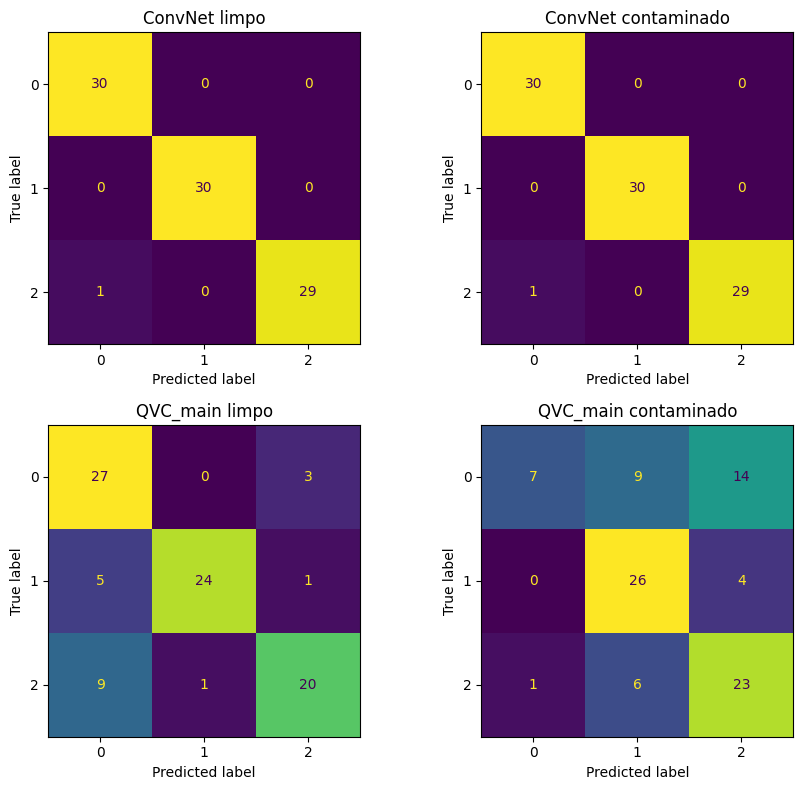

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
pairs = [
    ("ConvNet", convnet, convnet_poisoned),
    ("QVC_main", qvc_main, qvc_main_poisoned),
]
for row, (name, clean_model, poisoned_model) in enumerate(pairs):
    cm_clean = confusion_matrix(test_labels, model_predict(clean_model, X_test_img, X_test_flat))
    cm_poisoned = confusion_matrix(test_labels, model_predict(poisoned_model, X_test_img, X_test_flat))
    ConfusionMatrixDisplay(cm_clean).plot(ax=axes[row, 0], colorbar=False)
    axes[row, 0].set_title(f"{name} limpo")
    ConfusionMatrixDisplay(cm_poisoned).plot(ax=axes[row, 1], colorbar=False)
    axes[row, 1].set_title(f"{name} contaminado")
plt.tight_layout()
plt.show()

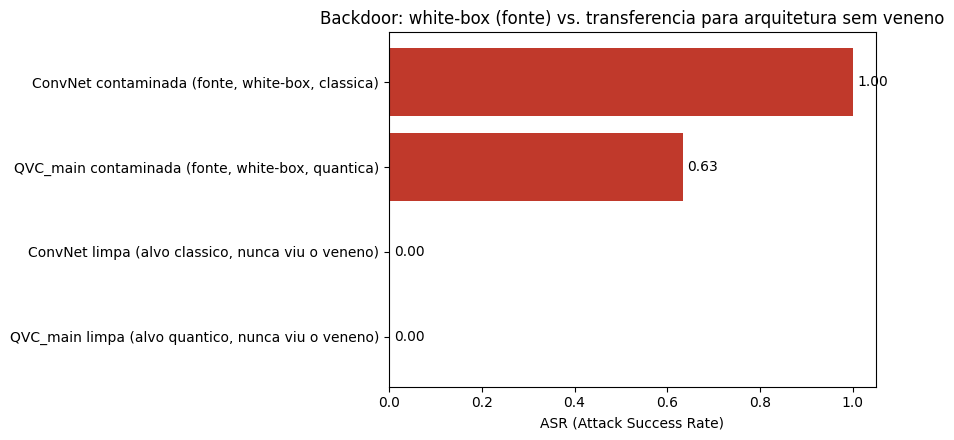

In [19]:
asr_transfer = {
    "ConvNet contaminada (fonte, white-box, classica)": asr(convnet_poisoned),
    "QVC_main contaminada (fonte, white-box, quantica)": asr(qvc_main_poisoned),
    "ConvNet limpa (alvo classico, nunca viu o veneno)": asr(convnet),
    "QVC_main limpa (alvo quantico, nunca viu o veneno)": asr(qvc_main),
}

labels_bar = list(asr_transfer.keys())
values_bar = list(asr_transfer.values())
colors_bar = ["#c0392b", "#c0392b", "#2980b9", "#2980b9"]

plt.figure(figsize=(9, 4.5))
bars = plt.barh(labels_bar, values_bar, color=colors_bar)
plt.xlim(0, 1.05)
plt.xlabel("ASR (Attack Success Rate)")
plt.title("Backdoor: white-box (fonte) vs. transferencia para arquitetura sem veneno")
for bar, v in zip(bars, values_bar):
    plt.text(v + 0.01, bar.get_y() + bar.get_height() / 2, f"{v:.2f}", va="center")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Interpretação esperada

- Acurácia limpa do modelo contaminado deve ficar próxima da acurácia do modelo limpo (o patch é raro no treino).
- ASR alta apenas nos modelos que **viram o veneno diretamente** (ConvNet/MLP/QVC_main/QVC_B contaminados); nos modelos limpos de arquitetura diferente, a ASR deve ficar próxima da taxa basal (o backdoor é específico do modelo, ao contrário das perturbações adversariais de evasão vistas mais adiante).
- Por ser um patch grande e de alto contraste, esse ataque deve ser o **mais fácil de detectar visualmente** entre os cinco reproduzidos neste repositório.

# Ferramentas de ataque adversarial (FGSM / PGD)

Implementamos os dois ataques usados no artigo que não exigem uma dependência extra pesada (o artigo também usa AutoAttack, mas omitimos aqui pela mesma razão do notebook irmão `main_c.ipynb`: manter o número de dependências baixo).

- **ConvNet/MLP (PyTorch)**: gradiente **exato** via `torch.autograd`.
- **QVC (NumPy)**: como o simulador não tem autodiff, o gradiente em relação à **entrada** (784 pixels) é estimado por **SPSA** (Simultaneous Perturbation Stochastic Approximation) — uma técnica padrão de estimação de gradiente por diferenças finitas em uma única direção aleatória, muito mais barata que diferenças finitas coordenada-a-coordenada quando a entrada tem centenas de dimensões.

Ambos respeitam a mesma grade de força de ataque ε (norma l∞) usada no artigo.

In [20]:
def fgsm_attack_torch(model, X_img, y, eps):
    """Fast Gradient Sign Method, gradiente exato via autograd do PyTorch."""
    model.eval()
    X_t = torch.as_tensor(X_img, dtype=torch.float32).clone().requires_grad_(True)
    y_t = torch.as_tensor(y, dtype=torch.long)
    loss = F.cross_entropy(model(X_t), y_t)
    grad = torch.autograd.grad(loss, X_t)[0]
    X_adv = X_t + eps * grad.sign()
    return X_adv.clamp(0.0, 1.0).detach().numpy()


def pgd_attack_torch(model, X_img, y, eps, steps=4, alpha=None):
    """Projected Gradient Descent, gradiente exato via autograd do PyTorch,
    com projecao na bola L_infinito de raio eps a cada passo."""
    if alpha is None:
        alpha = max(eps / steps * 1.5, 1e-3)
    model.eval()
    X0 = torch.as_tensor(X_img, dtype=torch.float32)
    y_t = torch.as_tensor(y, dtype=torch.long)
    X_adv = X0.clone()
    for _ in range(steps):
        X_adv.requires_grad_(True)
        loss = F.cross_entropy(model(X_adv), y_t)
        grad = torch.autograd.grad(loss, X_adv)[0]
        X_adv = X_adv.detach() + alpha * grad.sign()
        X_adv = torch.max(torch.min(X_adv, X0 + eps), X0 - eps)
        X_adv = X_adv.clamp(0.0, 1.0)
    return X_adv.numpy()

In [21]:
def qvc_input_gradient_spsa(qvc, X_flat, y, n_repeats=5, c=0.05, rng=None):
    """Estimador SPSA do gradiente da perda em relacao a entrada: em vez de
    perturbar cada um dos 784 pixels individualmente (custaria 784*2 chamadas
    por passo), perturba TODOS os pixels de uma vez com um vetor aleatorio de
    sinais (+1/-1) e usa a diferenca de perda nessa unica direcao. Repetir
    `n_repeats` vezes e tirar a media reduz a variancia. Isso troca precisao
    por um ganho de ~150x em chamadas ao simulador, essencial para viabilizar
    PGD/FGSM numa QVC de entrada 784-dimensional simulada em NumPy."""
    rng = rng or np.random.default_rng()
    grad_accum = np.zeros_like(X_flat)
    for _ in range(n_repeats):
        delta = rng.choice([-1.0, 1.0], size=X_flat.shape)
        Xp = np.clip(X_flat + c * delta, 0.0, 1.0)
        Xm = np.clip(X_flat - c * delta, 0.0, 1.0)
        loss_p = cross_entropy_per_sample(qvc.predict_proba(Xp), y)
        loss_m = cross_entropy_per_sample(qvc.predict_proba(Xm), y)
        grad_accum += ((loss_p - loss_m) / (2 * c))[:, None] * delta
    return grad_accum / n_repeats


def fgsm_attack_qvc(qvc, X_flat, y, eps, n_repeats=5, c=0.05, rng=None):
    g = qvc_input_gradient_spsa(qvc, X_flat, y, n_repeats=n_repeats, c=c, rng=rng)
    return np.clip(X_flat + eps * np.sign(g), 0.0, 1.0)


def pgd_attack_qvc(qvc, X_flat, y, eps, steps=4, alpha=None, n_repeats=5, c=0.05, rng=None):
    rng = rng or np.random.default_rng()
    if alpha is None:
        alpha = max(eps / steps * 1.5, 1e-3)
    X0 = X_flat.copy()
    X_adv = X_flat.copy()
    for _ in range(steps):
        g = qvc_input_gradient_spsa(qvc, X_adv, y, n_repeats=n_repeats, c=c, rng=rng)
        X_adv = X_adv + alpha * np.sign(g)
        X_adv = np.clip(X_adv, X0 - eps, X0 + eps)  # projecao na bola L_infinito
        X_adv = np.clip(X_adv, 0.0, 1.0)             # dominio dos pixels
    return X_adv

In [22]:
def generate_attack(model, X_img, X_flat, y, eps, attack, steps=4):
    """Gera exemplos adversariais white-box em `model` e devolve tanto a
    representacao de imagem quanto a achatada (as duas sao a mesma imagem,
    apenas remodelada, entao a conversao e trivial e sem perda)."""
    if eps == 0:
        return X_img, X_flat
    if isinstance(model, QVC):
        if attack == "fgsm":
            adv_flat = fgsm_attack_qvc(model, X_flat, y, eps)
        else:
            adv_flat = pgd_attack_qvc(model, X_flat, y, eps, steps=steps)
        return adv_flat.reshape(-1, 1, 28, 28), adv_flat
    else:
        if attack == "fgsm":
            adv_img = fgsm_attack_torch(model, X_img, y, eps)
        else:
            adv_img = pgd_attack_torch(model, X_img, y, eps, steps=steps)
        return adv_img, adv_img.reshape(len(adv_img), -1)


def transfer_sweep(source, targets, X_img, X_flat, y, eps_values, attack, steps=4):
    """Gera ataque white-box em `source` para cada eps e mede a acuracia de
    cada rede em `targets` (dict nome -> modelo) sobre os mesmos exemplos
    adversariais. Replica a mecanica da Fig. 2 do artigo."""
    rows = []
    for eps in eps_values:
        adv_img, adv_flat = generate_attack(source, X_img, X_flat, y, eps, attack, steps=steps)
        row = {"eps": eps}
        for name, tgt in targets.items():
            preds = model_predict(tgt, adv_img, adv_flat)
            row[name] = float(np.mean(preds == y))
        rows.append(row)
    return pd.DataFrame(rows)

# Transferibilidade e defesa (replica Fig. 2)

Seguindo a metodologia do artigo: para cada tipo de ataque (FGSM, PGD), geramos exemplos adversariais **white-box** numa rede-fonte e medimos a acurácia de **todas** as redes (a própria fonte, sua "irmã" da mesma família e as duas redes da família oposta) em função de ε. Isso reproduz as quatro combinações da Fig. 2:

- **Transferibilidade clássica**: ataque na ConvNet → acurácia da MLP cai também?
- **Defesa quântica**: ataque na ConvNet → QVC_main/QVC_B resistem?
- **Transferibilidade quântica**: ataque na QVC_main → acurácia da QVC_B cai também?
- **Defesa clássica**: ataque na QVC_main → ConvNet/MLP resistem?

As quatro redes (`ConvNet`, `MLP`, `QVC_main`, `QVC_B`) já foram treinadas nas seções anteriores.

In [23]:
EPS_VALUES = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]  # mesma grade do artigo (norma l_infinito)

targets_all = {"ConvNet": convnet, "MLP": mlp_torch, "QVC_main": qvc_main, "QVC_B": qvc_b}

print("Ataque FGSM a partir da ConvNet...")
df_fgsm_from_convnet = transfer_sweep(convnet, targets_all, X_test_img, X_test_flat, test_labels, EPS_VALUES, attack="fgsm")

print("Ataque FGSM a partir da QVC_main...")
df_fgsm_from_qvc = transfer_sweep(qvc_main, targets_all, X_test_img, X_test_flat, test_labels, EPS_VALUES, attack="fgsm")

print("Ataque PGD a partir da ConvNet...")
df_pgd_from_convnet = transfer_sweep(convnet, targets_all, X_test_img, X_test_flat, test_labels, EPS_VALUES, attack="pgd", steps=4)

print("Ataque PGD a partir da QVC_main...")
df_pgd_from_qvc = transfer_sweep(qvc_main, targets_all, X_test_img, X_test_flat, test_labels, EPS_VALUES, attack="pgd", steps=4)

print("\n=== FGSM | fonte ConvNet ===")
print(df_fgsm_from_convnet.round(3).to_string(index=False))
print("\n=== FGSM | fonte QVC_main ===")
print(df_fgsm_from_qvc.round(3).to_string(index=False))
print("\n=== PGD | fonte ConvNet ===")
print(df_pgd_from_convnet.round(3).to_string(index=False))
print("\n=== PGD | fonte QVC_main ===")
print(df_pgd_from_qvc.round(3).to_string(index=False))

Ataque FGSM a partir da ConvNet...


Ataque FGSM a partir da QVC_main...


Ataque PGD a partir da ConvNet...


Ataque PGD a partir da QVC_main...



=== FGSM | fonte ConvNet ===
 eps  ConvNet   MLP  QVC_main  QVC_B
0.00    0.989 0.978     0.789  0.667
0.05    0.978 0.967     0.611  0.644
0.10    0.967 0.844     0.422  0.456
0.15    0.811 0.556     0.389  0.333
0.20    0.456 0.411     0.344  0.333
0.30    0.033 0.100     0.300  0.311

=== FGSM | fonte QVC_main ===
 eps  ConvNet   MLP  QVC_main  QVC_B
0.00    0.989 0.978     0.789  0.667
0.05    0.978 0.978     0.644  0.667
0.10    0.978 0.967     0.444  0.622
0.15    0.978 0.967     0.400  0.489
0.20    0.989 0.922     0.367  0.400
0.30    0.922 0.667     0.311  0.322

=== PGD | fonte ConvNet ===
 eps  ConvNet   MLP  QVC_main  QVC_B
0.00    0.989 0.978     0.789  0.667
0.05    0.978 0.967     0.633  0.656
0.10    0.967 0.833     0.444  0.567
0.15    0.733 0.544     0.389  0.367
0.20    0.367 0.400     0.356  0.322
0.30    0.000 0.078     0.322  0.311

=== PGD | fonte QVC_main ===
 eps  ConvNet   MLP  QVC_main  QVC_B
0.00    0.989 0.978     0.789  0.667
0.05    0.978 0.978     0.633

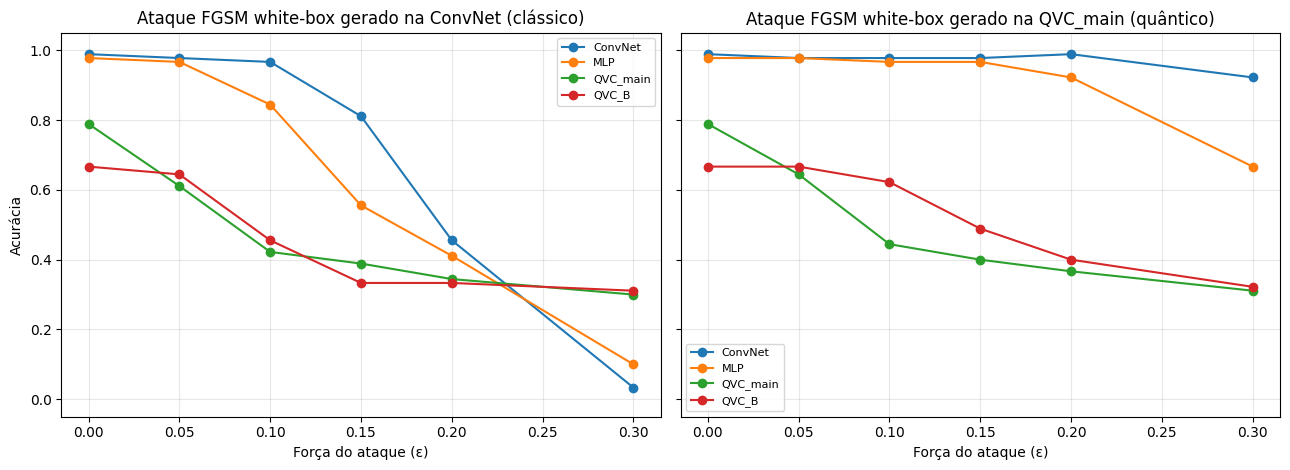

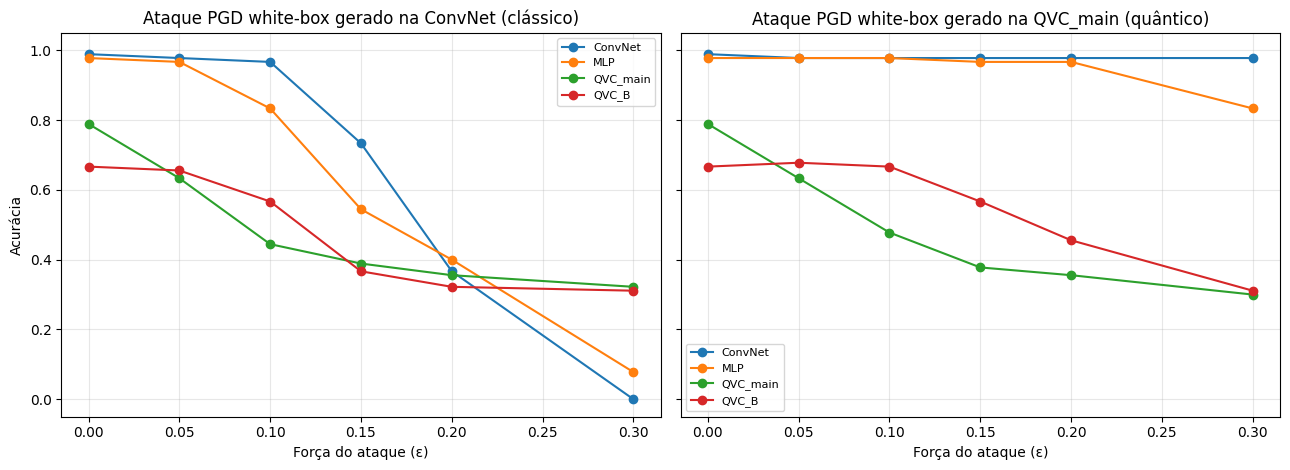

Linha de cima esperada (igual Fig.2 do artigo): ConvNet/MLP despencam
(transferibilidade classica), QVC_main/QVC_B resistem bem (defesa quantica).
Linha de baixo esperada: QVC_main/QVC_B despencam (transferibilidade
quantica, mais fraca que a classica), ConvNet/MLP tambem podem cair
bastante (fraca defesa classica contra ataque quantico), replicando a
assimetria central do artigo.


In [24]:
def plot_transfer(df_top, df_bottom, attack_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
    for col in df_top.columns:
        if col == "eps":
            continue
        axes[0].plot(df_top["eps"], df_top[col], marker="o", label=col)
    for col in df_bottom.columns:
        if col == "eps":
            continue
        axes[1].plot(df_bottom["eps"], df_bottom[col], marker="o", label=col)

    axes[0].set_title(f"Ataque {attack_name} white-box gerado na ConvNet (cl\u00e1ssico)")
    axes[1].set_title(f"Ataque {attack_name} white-box gerado na QVC_main (qu\u00e2ntico)")
    for ax in axes:
        ax.set_xlabel("For\u00e7a do ataque (\u03b5)")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Acur\u00e1cia")
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_transfer(df_fgsm_from_convnet, df_fgsm_from_qvc, "FGSM")
plot_transfer(df_pgd_from_convnet, df_pgd_from_qvc, "PGD")

print("Linha de cima esperada (igual Fig.2 do artigo): ConvNet/MLP despencam")
print("(transferibilidade classica), QVC_main/QVC_B resistem bem (defesa quantica).")
print("Linha de baixo esperada: QVC_main/QVC_B despencam (transferibilidade")
print("quantica, mais fraca que a classica), ConvNet/MLP tambem podem cair")
print("bastante (fraca defesa classica contra ataque quantico), replicando a")
print("assimetria central do artigo.")

# Conteúdo das perturbações adversariais (replica Fig. 3)

O artigo reporta uma diferença qualitativa marcante: as perturbações PGD geradas na rede clássica são um ruído de alta frequência incompreensível, enquanto as geradas na QVC alteram traços grandes e semanticamente reconhecíveis da imagem (ex.: preencher o vão das pernas de uma calça). Replicamos a mesma visualização — perturbação = `imagem_atacada - imagem_limpa` — para alguns dígitos do MNIST.

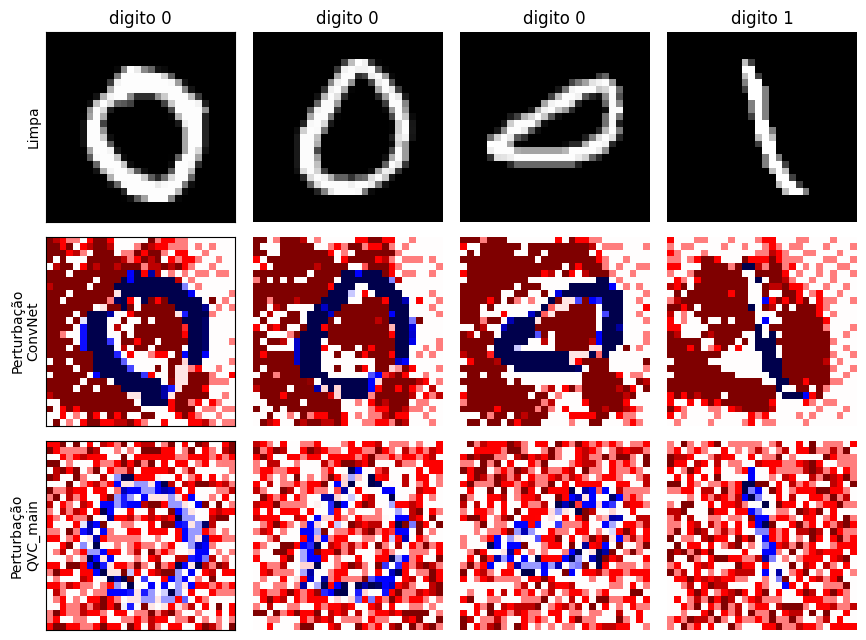

Compare visualmente: o artigo relata que a perturbacao da ConvNet e um
ruido de alta frequencia sem sentido, enquanto a da QVC tende a alterar
tracos grandes e reconheciveis do digito. Com poucas camadas (N_LAYERS)
a QVC pode nao mostrar esse efeito tao claramente quanto no artigo.


In [25]:
EPS_PERTURBATION_VIZ = 0.15
N_EXAMPLES_VIZ = 4

viz_idx = np.arange(N_EXAMPLES_VIZ)
X_viz_img = X_test_img[viz_idx]
X_viz_flat = X_test_flat[viz_idx]
y_viz = test_labels[viz_idx]

adv_convnet_img = pgd_attack_torch(convnet, X_viz_img, y_viz, eps=EPS_PERTURBATION_VIZ, steps=6)
perturb_convnet = (adv_convnet_img - X_viz_img).reshape(N_EXAMPLES_VIZ, 28, 28)

adv_qvc_flat = pgd_attack_qvc(qvc_main, X_viz_flat, y_viz, eps=EPS_PERTURBATION_VIZ, steps=6, n_repeats=6)
perturb_qvc = (adv_qvc_flat - X_viz_flat).reshape(N_EXAMPLES_VIZ, 28, 28)

fig, axes = plt.subplots(3, N_EXAMPLES_VIZ, figsize=(2.2 * N_EXAMPLES_VIZ, 6.5))
for j in range(N_EXAMPLES_VIZ):
    axes[0, j].imshow(X_viz_img[j, 0], cmap="gray")
    axes[0, j].set_title(f"digito {SELECTED_CLASSES[y_viz[j]]}")
    axes[1, j].imshow(perturb_convnet[j], cmap="seismic", vmin=-EPS_PERTURBATION_VIZ, vmax=EPS_PERTURBATION_VIZ)
    axes[2, j].imshow(perturb_qvc[j], cmap="seismic", vmin=-EPS_PERTURBATION_VIZ, vmax=EPS_PERTURBATION_VIZ)
    for i in range(3):
        axes[i, j].axis("off")
axes[0, 0].set_ylabel("Limpa"); axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
axes[1, 0].set_ylabel("Perturba\u00e7\u00e3o\nConvNet"); axes[1, 0].axis("on"); axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
axes[2, 0].set_ylabel("Perturba\u00e7\u00e3o\nQVC_main"); axes[2, 0].axis("on"); axes[2, 0].set_xticks([]); axes[2, 0].set_yticks([])
plt.tight_layout()
plt.show()

print("Compare visualmente: o artigo relata que a perturbacao da ConvNet e um")
print("ruido de alta frequencia sem sentido, enquanto a da QVC tende a alterar")
print("tracos grandes e reconheciveis do digito. Com poucas camadas (N_LAYERS)")
print("a QVC pode nao mostrar esse efeito tao claramente quanto no artigo.")

# Treinamento adversarial (replica Fig. 4, reduzido)

O artigo treina versões adversarialmente treinadas da QVC e do ConvNet (incluindo exemplos PGD no treino) e observa que isso ajuda **muito** a rede clássica mas **pouco** a QVC. Replicamos essa comparação numa única força de ataque (`EPS_ADV_TRAIN`, em vez das três do artigo: 0.1/0.2/0.3), retreinando:

- **ConvNet**: treinamento adversarial clássico de verdade (a cada mini-lote, gera PGD com os pesos atuais do modelo e treina 50% limpo / 50% adversarial) — igual ao artigo, viável porque temos gradiente exato via autograd.
- **QVC**: como o otimizador usado (COBYLA) opera em lote único (não é SGD por mini-lotes), regenerar adversários a cada "mini-lote" seria proibitivo. Em vez disso fazemos uma única rodada de **aumento de dados**: gera-se PGD contra a QVC já treinada e re-otimiza-se sobre {dados limpos + dados adversariais}. Essa é uma simplificação declarada do treinamento adversarial iterativo do artigo, mas mede a mesma pergunta (a QVC melhora sua robustez depois de "ver" adversários?).

In [26]:
def train_torch_model_adversarial(model, X_img, y, epochs=15, lr=1e-3, batch_size=32, eps=0.15, pgd_steps=3):
    """Treinamento adversarial classico: a cada mini-lote, gera PGD com os
    pesos ATUAIS do modelo e treina com a mistura 50% limpo / 50% adversarial
    (mesma proporcao usada no Apendice A do artigo)."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    X_all = torch.as_tensor(X_img, dtype=torch.float32)
    y_all = torch.as_tensor(y, dtype=torch.long)
    n = len(X_all)
    for epoch in range(epochs):
        perm = torch.randperm(n)
        total_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_all[idx], y_all[idx]
            xb_adv_np = pgd_attack_torch(model, xb.numpy(), yb.numpy(), eps=eps, steps=pgd_steps)
            xb_mix = torch.cat([xb, torch.as_tensor(xb_adv_np, dtype=torch.float32)], dim=0)
            yb_mix = torch.cat([yb, yb], dim=0)
            model.train()
            opt.zero_grad()
            loss = loss_fn(model(xb_mix), yb_mix)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(xb_mix)
        if (epoch + 1) % 5 == 0:
            print(f"  [adv] epoch {epoch+1:2d}/{epochs} - loss {total_loss/(2*n):.4f}")
    model.eval()
    return model


EPS_ADV_TRAIN = 0.15  # forca do PGD usado no treinamento adversarial (artigo usa 0.1/0.2/0.3)

convnet_adv = ConvNet(N_CLASSES)
convnet_adv.load_state_dict(convnet.state_dict())  # comeca dos pesos ja treinados (mais rapido)
convnet_adv = train_torch_model_adversarial(convnet_adv, X_train_img, train_labels, epochs=15, eps=EPS_ADV_TRAIN)

acc_convnet_adv_clean = torch_accuracy(convnet_adv, X_test_img, test_labels)
print(f"Acuracia limpa ConvNet (original)     : {acc_convnet_clean:.4f}")
print(f"Acuracia limpa ConvNet (adv. training): {acc_convnet_adv_clean:.4f}")

  [adv] epoch  5/15 - loss 0.1611


  [adv] epoch 10/15 - loss 0.1262


  [adv] epoch 15/15 - loss 0.0996
Acuracia limpa ConvNet (original)     : 0.9889
Acuracia limpa ConvNet (adv. training): 0.9889


In [27]:
# O otimizador COBYLA usado para treinar a QVC opera sobre o LOTE INTEIRO (nao
# eh SGD por mini-lotes), entao nao da para "regenerar adversarios a cada
# batch" como fazemos com a ConvNet. Em vez disso, replicamos o espirito do
# treinamento adversarial com uma unica rodada de aumento de dados: geramos
# PGD contra a QVC ja treinada e re-otimizamos (a partir dos pesos atuais)
# sobre o conjunto {dados limpos + dados adversariais}.
print("Gerando exemplos adversariais (PGD) contra a QVC_main treinada...")
X_train_adv_flat = pgd_attack_qvc(
    qvc_main, X_train_flat, train_labels, eps=EPS_ADV_TRAIN, steps=3, n_repeats=5
)

X_train_aug_flat = np.vstack([X_train_flat, X_train_adv_flat])
y_train_aug = np.concatenate([train_labels, train_labels])

qvc_main_adv = QVC(n_qubits=N_QUBITS, n_layers=N_LAYERS, n_classes=N_CLASSES, seed=0)
qvc_main_adv.weights = qvc_main.weights.copy()  # warm start a partir da QVC ja treinada

print("Re-otimizando a QVC sobre o conjunto aumentado (limpo + adversarial)...")
qvc_main_adv.fit(X_train_aug_flat, y_train_aug, maxiter=150)

acc_qvc_adv_clean = float(np.mean(qvc_main_adv.predict(X_test_flat) == test_labels))
print(f"Acuracia limpa QVC_main (original)        : {acc_qvc_main_clean:.4f}")
print(f"Acuracia limpa QVC_main (adv. training)    : {acc_qvc_adv_clean:.4f}")

Gerando exemplos adversariais (PGD) contra a QVC_main treinada...


Re-otimizando a QVC sobre o conjunto aumentado (limpo + adversarial)...


  iter   30/150 - loss 1.0543


  iter   60/150 - loss 1.0518


  iter   90/150 - loss 1.0482


  iter  120/150 - loss 1.0463


  iter  150/150 - loss 1.0399
  fim - loss final 1.0399 (150 avaliacoes)


Acuracia limpa QVC_main (original)        : 0.7889
Acuracia limpa QVC_main (adv. training)    : 0.8333


Gerando ataque PGD a partir da ConvNet original...


Gerando ataque PGD a partir da QVC_main original...


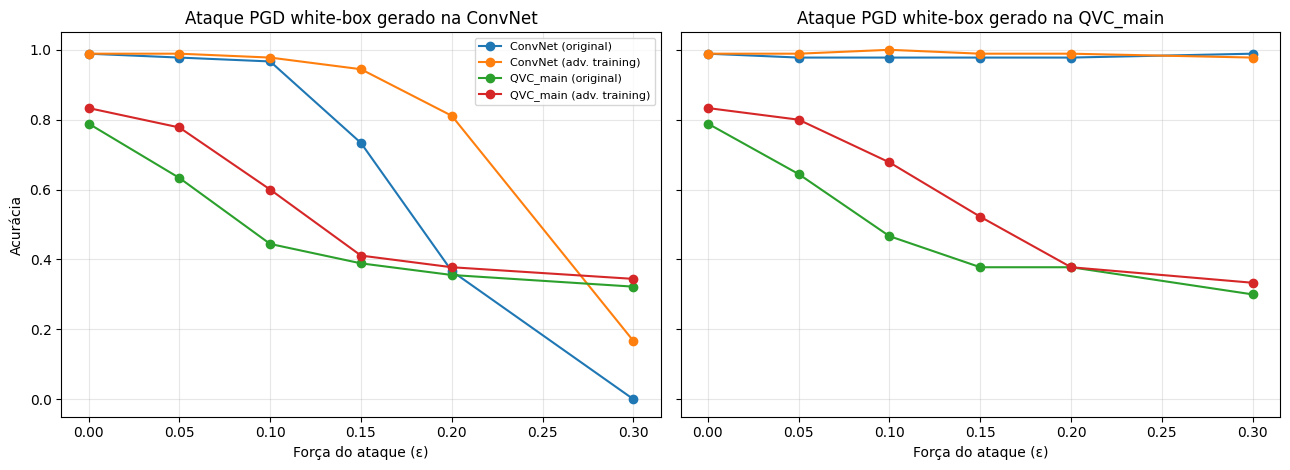


Expectativa do artigo: treinamento adversarial ajuda MUITO a ConvNet e
pouco a QVC (o gargalo do treinamento COBYLA/estatico aqui reforca essa assimetria).


In [28]:
# Compara os modelos ORIGINAIS com os modelos ADVERSARIALMENTE TREINADOS,
# sob o mesmo ataque PGD white-box, gerado a partir da rede ORIGINAL em cada caso
# (mesma metodologia da Fig. 4 do artigo: ataque fixo, compara-se a defesa).
targets_adv_compare = {
    "ConvNet (original)": convnet,
    "ConvNet (adv. training)": convnet_adv,
    "QVC_main (original)": qvc_main,
    "QVC_main (adv. training)": qvc_main_adv,
}

print("Gerando ataque PGD a partir da ConvNet original...")
df_adv_panel_a = transfer_sweep(
    convnet, targets_adv_compare, X_test_img, X_test_flat, test_labels, EPS_VALUES, attack="pgd", steps=4
)

print("Gerando ataque PGD a partir da QVC_main original...")
df_adv_panel_b = transfer_sweep(
    qvc_main, targets_adv_compare, X_test_img, X_test_flat, test_labels, EPS_VALUES, attack="pgd", steps=4
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for col in targets_adv_compare:
    axes[0].plot(df_adv_panel_a["eps"], df_adv_panel_a[col], marker="o", label=col)
    axes[1].plot(df_adv_panel_b["eps"], df_adv_panel_b[col], marker="o", label=col)

axes[0].set_title("Ataque PGD white-box gerado na ConvNet")
axes[1].set_title("Ataque PGD white-box gerado na QVC_main")
for ax in axes:
    ax.set_xlabel("For\u00e7a do ataque (\u03b5)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Acur\u00e1cia")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nExpectativa do artigo: treinamento adversarial ajuda MUITO a ConvNet e")
print("pouco a QVC (o gargalo do treinamento COBYLA/estatico aqui reforca essa assimetria).")

# Detecção de ataque adversarial (replica Fig. 5)

Ideia do artigo (Seção II.E): como a QVC costuma **resistir** a ataques gerados numa rede clássica (e vice-versa nem tanto), um **ataque é sinalizado quando a ConvNet e a QVC discordam** na predição. Testamos essa regra com uma mistura de imagens limpas e atacadas (tipo de ataque, força ε e rede-fonte sorteados aleatoriamente por imagem, como no artigo), medindo:

- **Falso positivo**: ConvNet e QVC discordam numa imagem **limpa** (não deveria acontecer).
- **Verdadeiro positivo**: ConvNet e QVC discordam numa imagem **atacada** (o objetivo da técnica).

In [29]:
rng_detect = np.random.default_rng(7)

DETECT_EPS_OPTIONS = [0.1, 0.2, 0.3]
DETECT_ATTACK_OPTIONS = ["fgsm", "pgd"]
DETECT_SOURCE_OPTIONS = ["ConvNet", "QVC_main"]

n_test = len(X_test_img)
assignment = pd.DataFrame({
    "idx": np.arange(n_test),
    "eps": rng_detect.choice(DETECT_EPS_OPTIONS, size=n_test),
    "attack": rng_detect.choice(DETECT_ATTACK_OPTIONS, size=n_test),
    "source": rng_detect.choice(DETECT_SOURCE_OPTIONS, size=n_test),
})

X_detect_img = X_test_img.copy()
X_detect_flat = X_test_flat.copy()

# Gera os exemplos atacados agrupando por (eps, ataque, fonte) para reaproveitar
# o processamento em lote das funcoes de ataque (muito mais rapido que atacar
# imagem por imagem).
for (eps, attack, source), group in assignment.groupby(["eps", "attack", "source"]):
    idx = group["idx"].to_numpy()
    src_model = convnet if source == "ConvNet" else qvc_main
    adv_img, adv_flat = generate_attack(
        src_model, X_test_img[idx], X_test_flat[idx], test_labels[idx], eps, attack, steps=4
    )
    X_detect_img[idx] = adv_img
    X_detect_flat[idx] = adv_flat

pred_convnet_clean = model_predict(convnet, X_test_img, X_test_flat)
pred_qvc_clean = model_predict(qvc_main, X_test_img, X_test_flat)
disagree_clean = pred_convnet_clean != pred_qvc_clean

pred_convnet_atk = model_predict(convnet, X_detect_img, X_detect_flat)
pred_qvc_atk = model_predict(qvc_main, X_detect_img, X_detect_flat)
disagree_atk = pred_convnet_atk != pred_qvc_atk

false_positive_rate = float(np.mean(disagree_clean))
true_positive_rate = float(np.mean(disagree_atk))

print(f"Imagens limpas avaliadas   : {len(disagree_clean)}")
print(f"Imagens atacadas avaliadas : {len(disagree_atk)} (tipo/forca/fonte sorteados aleatoriamente)")
print()
print(f"Falsos positivos  (ConvNet x QVC discordam em imagem LIMPA)  : "
      f"{int(disagree_clean.sum())}/{len(disagree_clean)} ({false_positive_rate:.1%})")
print(f"Verdadeiros positivos (ConvNet x QVC discordam em imagem ATACADA): "
      f"{int(disagree_atk.sum())}/{len(disagree_atk)} ({true_positive_rate:.1%})")

Imagens limpas avaliadas   : 90
Imagens atacadas avaliadas : 90 (tipo/forca/fonte sorteados aleatoriamente)

Falsos positivos  (ConvNet x QVC discordam em imagem LIMPA)  : 18/90 (20.0%)
Verdadeiros positivos (ConvNet x QVC discordam em imagem ATACADA): 58/90 (64.4%)


## Reduções em relação ao artigo (West et al. 2023)

| Aspecto | Artigo (West et al. 2023) | Este notebook |
|---|---|---|
| Qubits (MNIST) | 10 | 10 (igual) |
| Camadas da QVC | 200 / 500 / 1000 | 10 (`QVC_main`) e 5 (`QVC_B`) |
| Classes | 10 (todos os dígitos) | 3 (`SELECTED_CLASSES`) |
| Imagens de treino | ~6000/classe | 80/classe |
| Imagens de teste (curvas) | 250 | 90 |
| Rede clássica | ConvNet grande + ResNet18 | CNN pequena + MLP (PyTorch) |
| Ataques | PGD, FGSM, AutoAttack | PGD, FGSM (sem AutoAttack) |
| Gradiente de entrada (QVC) | autodiff (Pennylane) | SPSA (estimador de gradiente por diferenças aleatórias, pois o simulador NumPy não tem autodiff) |
| Treinamento adversarial (QVC) | iterativo, a cada batch | aumento estático de dados (1 rodada), compatível com o otimizador COBYLA (não é SGD) |
| Simulação da QVC | Pennylane | Statevector em NumPy, escrito à mão e **validado numericamente contra Qiskit** |

Para aproximar mais do artigo, basta aumentar as constantes no topo do notebook (`SELECTED_CLASSES`, `N_PER_CLASS_TRAIN/TEST`, `N_LAYERS`, `maxiter` do COBYLA) — o código foi escrito para escalar sem mudanças estruturais, ao custo de tempo de execução maior (o gargalo principal é a geração de ataques PGD na QVC via SPSA e o treino COBYLA, ambos lineares no tamanho do lote e no número de camadas).

## Conclusão

Este notebook segue a **mesma metodologia** do artigo (amplitude encoding em qubits, QVC com camadas de rotação + CZ, ataques FGSM/PGD white-box, transferibilidade/defesa cruzada clássico↔quântico, treinamento adversarial e detecção por discordância), **acrescida** do backdoor de trigger explícito (`trigger_explicito/`), com comparação completa entre arquitetura clássica e quântica tanto para a evasão adversarial (Fig. 2-5) quanto para o backdoor (seção "Trojan"). Os demais notebooks desta pasta (`clean_label.ipynb`, `label_flip.ipynb`, `stealthy.ipynb`, `gradient_based_poisoning.ipynb`) reaproveitam esta mesma estrutura, trocando apenas o mecanismo de poisoning pela técnica correspondente.